In [5]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pykalman import KalmanFilter
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

In [6]:
# Scripts 
from src.local_config import *
from src.cointegration import *
from src.kalman import *
from src.pairs import *
from src.trading_signal import *
from src.backtest import *
from src.plots import *
from src.utils import *

In [7]:
# Load in data from previous notebook
df1_is = pd.read_csv(PROJECT_ROOT / "data/df1_is",
                     index_col=0, parse_dates=True)
df1_oos = pd.read_csv(PROJECT_ROOT / "data/df1_oos",
                      index_col=0, parse_dates=True)

df2_is = pd.read_csv(PROJECT_ROOT / "data/df2_is",
                     index_col=0, parse_dates=True)
df2_oos = pd.read_csv(PROJECT_ROOT / "data/df2_oos",
                      index_col=0, parse_dates=True)

static_results_df = pd.read_csv(PROJECT_ROOT / "data/static_hedge_ratio")
dynamic_results_df = pd.read_csv(PROJECT_ROOT / "data/dynamic_hedge_ratio")

In [8]:
# Load dictionaries from previous notebook
with open(PROJECT_ROOT / "data/dictionaries/static_spreads.pkl", "rb") as f:
    static_spreads = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/static_models.pkl", "rb") as f:
    static_models = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/dynamic_spreads.pkl", "rb") as f:
    dyamic_spreads = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details.pkl", "rb") as f:
    dynamic_details = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/is_results.pkl", "rb") as f:
    is_results = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/is_trading_signals.pkl", "rb") as f:
    is_trading_signals = pickle.load(f)

with open(PROJECT_ROOT / "data/dictionaries/oos_results.pkl", "rb") as f:
    oos_results = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/oos_trading_signals.pkl", "rb") as f:
    oos_trading_signals = pickle.load(f)

In [9]:
# Load risk-free rate to calculate sharpe ratio
rf_is = pd.read_csv(PROJECT_ROOT / "data/rf_is",
                     index_col=0, parse_dates=True) 
rf_oos = pd.read_csv(PROJECT_ROOT / "data/rf_oos",
                     index_col=0, parse_dates=True)

## In-Sample Backtest

In [10]:
is_trading_signals 

,strategy,pair,obs_cov,entry_z,exit_z,num_trades,mean_zscore,std_zscore
0,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,0.5,1.5,0.0,26.0,-0.074323,1.254340
1,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,1.0,1.5,0.0,26.0,-0.075102,1.296052
2,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,5.0,1.5,0.0,22.5,-0.075295,1.352083
3,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,1.5,0.0,28.5,0.088018,1.284509
4,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,1.0,1.5,0.0,27.5,0.090501,1.304701
...,...,...,...,...,...,...,...,...
157,entry_2.5_exit_1.0,3993 HK Equity vs 2689 HK Equity,1.0,2.5,1.0,18.5,0.079376,1.326103
158,entry_2.5_exit_1.0,3993 HK Equity vs 2689 HK Equity,5.0,2.5,1.0,18.0,0.066960,1.353544
159,entry_2.5_exit_1.0,1898 HK Equity vs 2386 HK Equity,0.5,2.5,1.0,20.0,-0.018652,1.295543
160,entry_2.5_exit_1.0,1898 HK Equity vs 2386 HK Equity,1.0,2.5,1.0,17.0,-0.025062,1.309947


In [11]:
is_summary_rows = []

for key, is_signals_dict in is_results.items():
    for (pair_name, R), df in is_signals_dict.items():

        df = compute_strategy_returns(df)

        is_mean_ret = df["strategy_ret"].mean()
        is_std_ret = df["strategy_ret"].std()

        sharpe = is_mean_ret / is_std_ret if is_std_ret != 0 else np.nan
        total_return = df["strategy_ret"].sum()

        is_summary_rows.append({
            "strategy": key,
            "pair": pair_name,
            "entry_z": float(key.split("_")[1]),
            "exit_z": float(key.split("_")[3]),
            "sharpe": sharpe,
            "total_return": total_return,
            "num_trades": df["position"].diff().abs().sum() / 2
        })

is_signals = pd.DataFrame(is_summary_rows)

In [12]:
# Find averages using pivot table
is_sharpe_pivot = is_signals.pivot_table(
    index="entry_z",
    columns="exit_z",
    values="sharpe",
    aggfunc="mean"
)

is_return_pivot = is_signals.pivot_table(
    index="entry_z",
    columns="exit_z",
    values="total_return",
    aggfunc="mean"
)

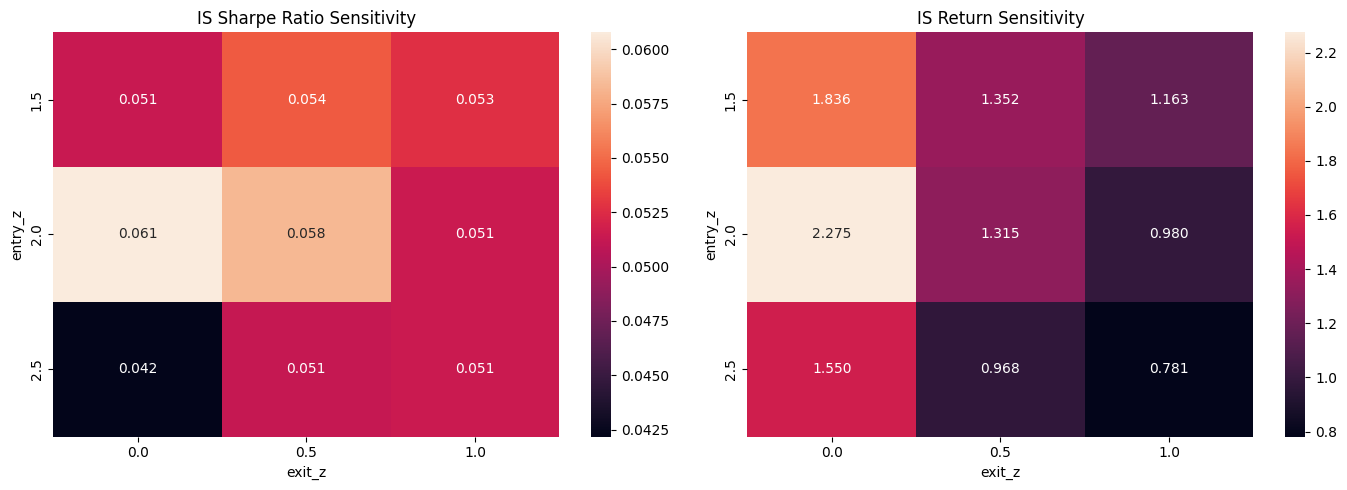

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    is_sharpe_pivot,
    annot=True,
    fmt=".3f",
    cmap="rocket",
    ax=axes[0]
)

axes[0].set_title("IS Sharpe Ratio Sensitivity")
axes[0].set_xlabel("exit_z")
axes[0].set_ylabel("entry_z")

sns.heatmap(
    is_return_pivot,
    annot=True,
    fmt=".3f",
    cmap="rocket",
    ax=axes[1]
)

axes[1].set_title("IS Return Sensitivity")
axes[1].set_xlabel("exit_z")
axes[1].set_ylabel("entry_z")

plt.tight_layout()
plt.show()

From our sensitivity analysis, we see it indicates that the strategy performs best using an entry threshold of 2.0 and an exit threshold of 0.0. This combination produces both the highest average Sharpe ratio and the highest average total return, suggesting that a moderate entry threshold provides the best balance between signal reliability and trade frequency. Lower entry thresholds may generate excessive trades based on weaker deviations, while higher thresholds may be too restrictive and reduce trading opportunities. The return heatmap also shows that exiting at 0.0 consistently outperforms exiting at 0.5 or 1.0, indicating that the strategy benefits from holding positions until the spread has fully reverted to its mean.

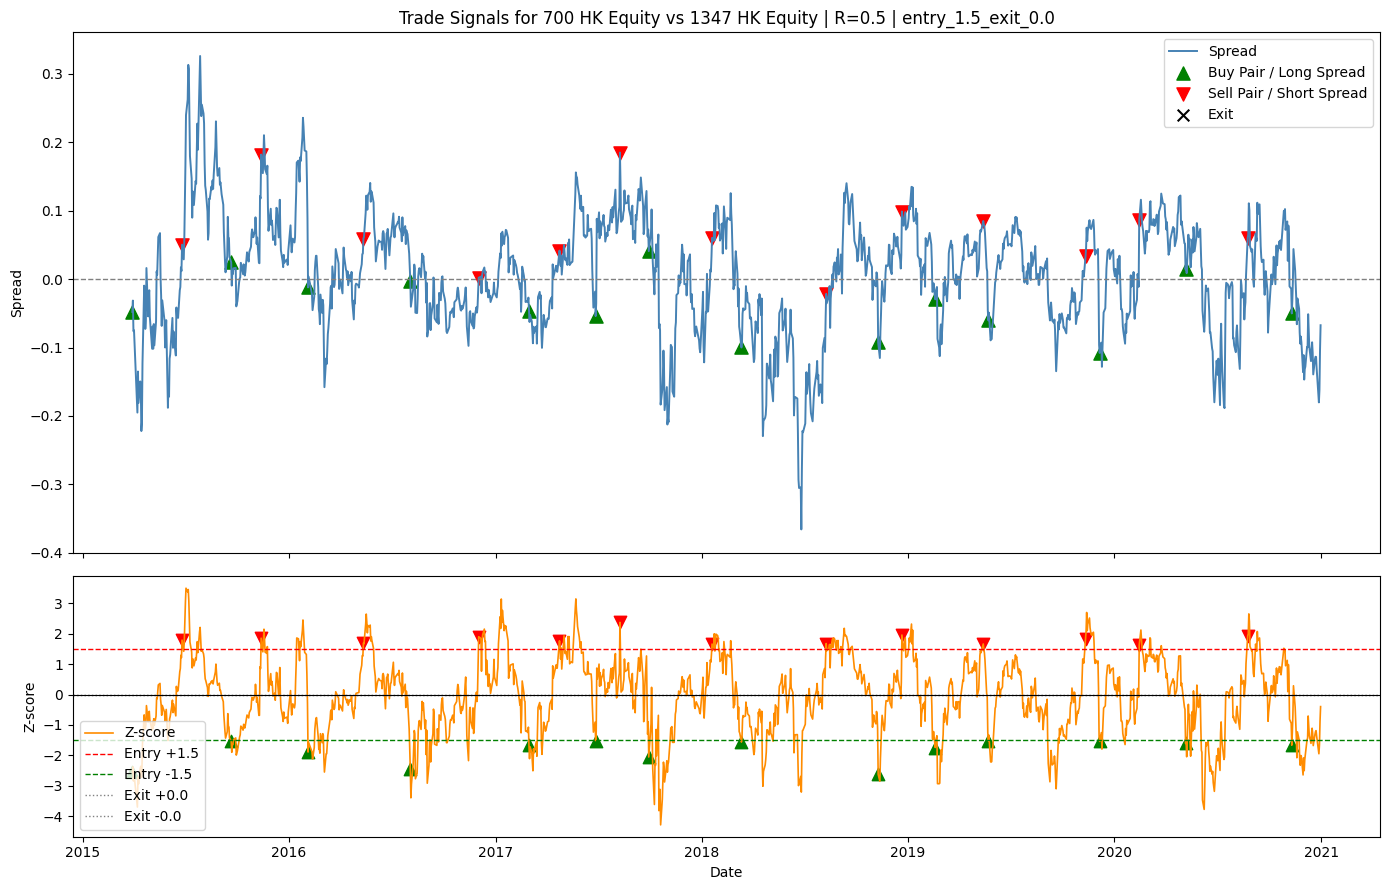

In [14]:
# Example: choose one strategy and one pair, then plot buy/sell/exit markers.
strategy_name = sorted(is_results.keys())[0]
pair_name, obs_cov = next(iter(is_results[strategy_name].keys()))

plot_trade_signals(
    results_dict=is_results,
    strategy_name=strategy_name,
    pair_name=pair_name,
    obs_cov=obs_cov
)

In [15]:
save_dir = PROJECT_ROOT / "outputs/trading_signal_plots_is"
os.makedirs(save_dir, exist_ok=True)

plt.ioff

for strategy_name in sorted(is_results.keys()):

    for pair_name, obs_cov in sorted(is_results[strategy_name].keys()):

        # Create the plot
        plot_trade_signals(
            results_dict=is_results,
            strategy_name=strategy_name,
            pair_name=pair_name,
            obs_cov=obs_cov
        )

        # Clean filename
        clean_pair_name = (
            pair_name
            .replace(" ", "_")
            .replace("/", "_")
            .replace("\\", "_")
            .replace(":", "_")
        )

        filename = f"{strategy_name}_{clean_pair_name}_R{obs_cov}.png"
        filepath = os.path.join(save_dir, filename)

        # Save current figure
        plt.savefig(filepath, dpi=300, bbox_inches="tight")

        # Close figure so memory doesn't build up
        plt.close()

print(f"Saved all trade signal plots to: {save_dir}")

Saved all trade signal plots to: /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/trading_signal_plots_is


### Performance metrics 

In [16]:
is_performance_metrics = performance_metrics(is_results, rf=rf_is)

In [17]:
is_performance_metrics[is_performance_metrics["strategy"]=="entry_1.5_exit_0.5"]

,strategy,pair,obs_cov,entry_z,exit_z,avg_return (%),avg_excess_return (%),total_pnl,sharpe,annualised_sharpe,hit_rate (%),num_trades
18,entry_1.5_exit_0.5,700 HK Equity vs 1347 HK Equity,0.5,1.5,0.5,0.147709,0.143849,2.094516,0.068304,1.084294,25.599436,44.5
19,entry_1.5_exit_0.5,700 HK Equity vs 1347 HK Equity,1.0,1.5,0.5,0.114387,0.110527,1.622011,0.046276,0.734611,25.881523,40.0
20,entry_1.5_exit_0.5,700 HK Equity vs 1347 HK Equity,5.0,1.5,0.5,0.093611,0.089751,1.327406,0.028673,0.455163,27.433004,36.5
21,entry_1.5_exit_0.5,1347 HK Equity vs 268 HK Equity,0.5,1.5,0.5,0.184647,0.180787,2.618289,0.071888,1.141188,29.125529,50.0
22,entry_1.5_exit_0.5,1347 HK Equity vs 268 HK Equity,1.0,1.5,0.5,0.149539,0.145679,2.120456,0.060050,0.953266,28.490832,44.0
23,entry_1.5_exit_0.5,1347 HK Equity vs 268 HK Equity,5.0,1.5,0.5,0.099714,0.095854,1.413946,0.037981,0.602936,25.952045,42.0
24,entry_1.5_exit_0.5,1088 HK Equity vs 3993 HK Equity,0.5,1.5,0.5,0.066746,0.062887,0.946464,0.050635,0.803812,26.939351,36.5
25,entry_1.5_exit_0.5,1088 HK Equity vs 3993 HK Equity,1.0,1.5,0.5,0.065227,0.061367,0.924912,0.047853,0.759637,28.138223,39.5
26,entry_1.5_exit_0.5,1088 HK Equity vs 3993 HK Equity,5.0,1.5,0.5,0.069559,0.065699,0.986344,0.047107,0.747801,29.196051,39.5
27,entry_1.5_exit_0.5,1088 HK Equity vs 1171 HK Equity,0.5,1.5,0.5,0.068837,0.064977,0.976103,0.070566,1.120205,23.413258,41.0


## OOS Backtest

In [18]:
oos_trading_signals

,strategy,pair,obs_cov,entry_z,exit_z,num_trades,mean_zscore,std_zscore
0,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,0.5,1.5,0.0,11.5,-0.033480,1.113476
1,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,1.0,1.5,0.0,8.5,-0.034495,1.128805
2,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,5.0,1.5,0.0,8.5,-0.012138,1.167276
3,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,0.5,1.5,0.0,7.5,0.003917,1.214942
4,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,1.0,1.5,0.0,7.5,-0.000489,1.232829
...,...,...,...,...,...,...,...,...
157,entry_2.5_exit_1.0,3993 HK Equity vs 2689 HK Equity,1.0,2.5,1.0,3.5,0.025793,1.151750
158,entry_2.5_exit_1.0,3993 HK Equity vs 2689 HK Equity,5.0,2.5,1.0,2.5,-0.044291,1.172397
159,entry_2.5_exit_1.0,1898 HK Equity vs 2386 HK Equity,0.5,2.5,1.0,4.0,-0.133279,1.290832
160,entry_2.5_exit_1.0,1898 HK Equity vs 2386 HK Equity,1.0,2.5,1.0,7.0,-0.124376,1.315200


In [19]:
oos_summary_rows = []

for key, oos_signals_dict in oos_results.items():
    for (pair_name, R), df in oos_signals_dict.items():

        df = compute_strategy_returns(df)

        oos_mean_ret = df["strategy_ret"].mean()
        oos_std_ret = df["strategy_ret"].std()

        sharpe = oos_mean_ret / oos_std_ret if oos_std_ret != 0 else np.nan
        total_return = df["strategy_ret"].sum()

        oos_summary_rows.append({
            "strategy": key,
            "pair": pair_name,
            "entry_z": float(key.split("_")[1]),
            "exit_z": float(key.split("_")[3]),
            "sharpe": sharpe,
            "total_return": total_return,
            "num_trades": df["position"].diff().abs().sum() / 2
        })

oos_signals = pd.DataFrame(oos_summary_rows)

In [20]:
oos_signals

,strategy,pair,entry_z,exit_z,sharpe,total_return,num_trades
0,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,1.5,0.0,0.172817,3.146184,11.5
1,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,1.5,0.0,0.125396,2.487092,8.5
2,entry_1.5_exit_0.0,700 HK Equity vs 1347 HK Equity,1.5,0.0,0.118821,2.596064,8.5
3,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,1.5,0.0,0.083074,1.354914,7.5
4,entry_1.5_exit_0.0,1347 HK Equity vs 268 HK Equity,1.5,0.0,0.087500,1.477494,7.5
...,...,...,...,...,...,...,...
157,entry_2.5_exit_1.0,3993 HK Equity vs 2689 HK Equity,2.5,1.0,0.037086,0.151739,3.5
158,entry_2.5_exit_1.0,3993 HK Equity vs 2689 HK Equity,2.5,1.0,0.029452,0.104710,2.5
159,entry_2.5_exit_1.0,1898 HK Equity vs 2386 HK Equity,2.5,1.0,0.049104,0.224621,4.0
160,entry_2.5_exit_1.0,1898 HK Equity vs 2386 HK Equity,2.5,1.0,0.097790,0.489071,7.0


In [21]:
# Find averages using pivot table
oos_sharpe_pivot = oos_signals.pivot_table(
    index="entry_z",
    columns="exit_z",
    values="sharpe",
    aggfunc="mean"
)

oos_return_pivot = oos_signals.pivot_table(
    index="entry_z",
    columns="exit_z",
    values="total_return",
    aggfunc="mean"
)

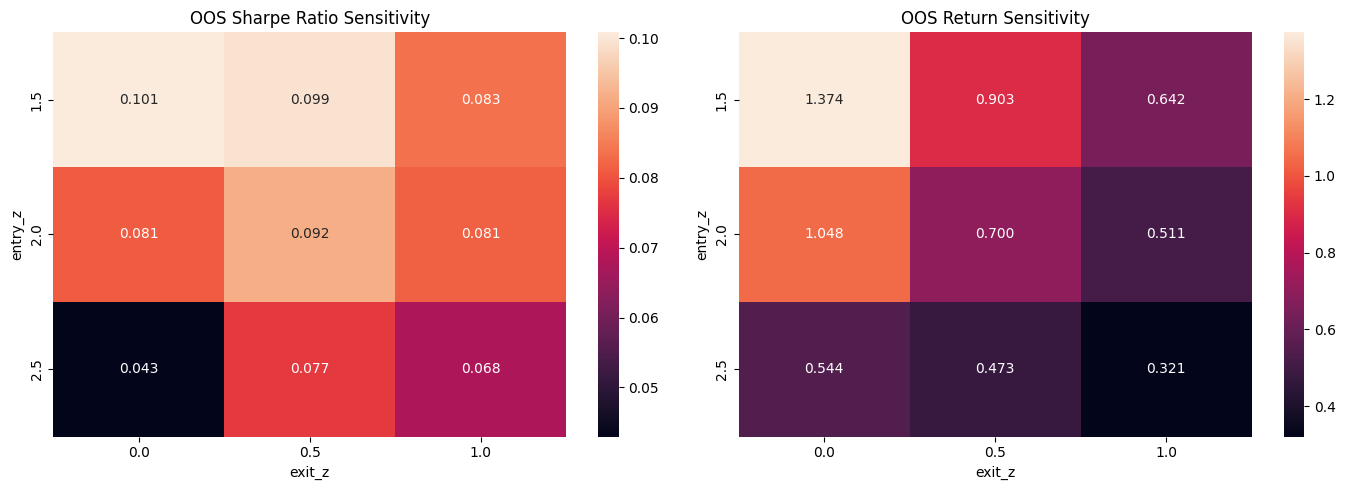

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    oos_sharpe_pivot,
    annot=True,
    fmt=".3f",
    cmap="rocket",
    ax=axes[0]
)

axes[0].set_title("OOS Sharpe Ratio Sensitivity")
axes[0].set_xlabel("exit_z")
axes[0].set_ylabel("entry_z")

sns.heatmap(
    oos_return_pivot,
    annot=True,
    fmt=".3f",
    cmap="rocket",
    ax=axes[1]
)

axes[1].set_title("OOS Return Sensitivity")
axes[1].set_xlabel("exit_z")
axes[1].set_ylabel("entry_z")

plt.tight_layout()
plt.show()

The out-of-sample sensitivity analysis indicates that the strongest performance is achieved using an entry threshold of 1.5 and an exit threshold of 0.0. This combination produces the highest average Sharpe ratio and total return across the tested pairs and Kalman filter observation covariance values. The results suggest that, out-of-sample, a less restrictive entry threshold allowed the strategy to capture more trading opportunities, whereas higher entry thresholds may have been too selective and reduced profitability. Across all entry thresholds, exiting at 0.0 generated the highest returns, indicating that the strategy benefited from holding positions until the spread fully reverted to its mean. Compared with the in-sample results, the optimal entry threshold shifts from 2.0 to 1.5, suggesting some parameter sensitivity; however, the preference for an exit threshold of 0.0 remains consistent across both samples.

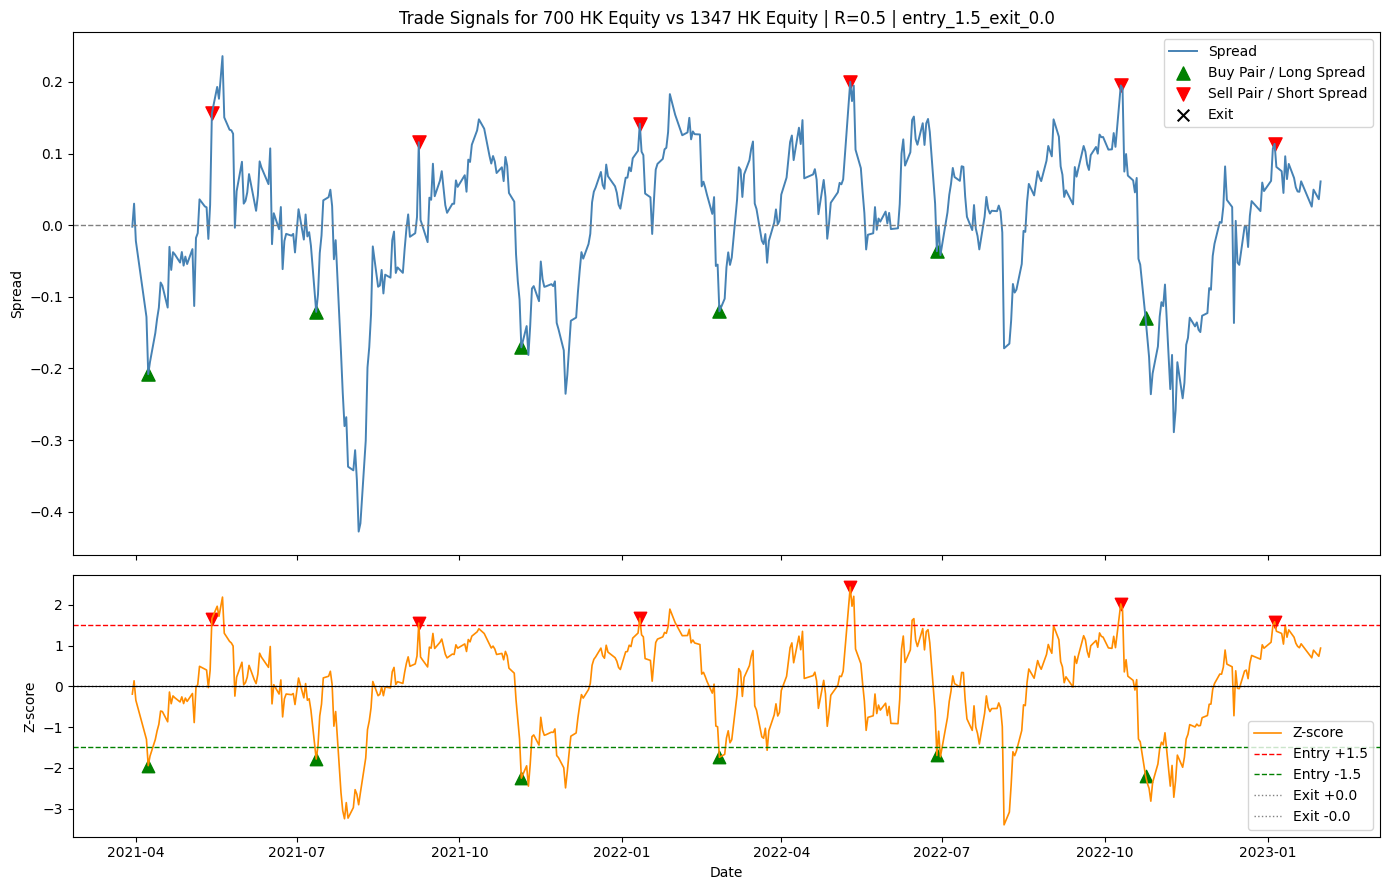

In [23]:
# Example: choose one strategy and one pair, then plot buy/sell/exit markers.
strategy_name = sorted(oos_results.keys())[0]
pair_name, obs_cov = next(iter(oos_results[strategy_name].keys()))

plot_trade_signals(
    results_dict=oos_results,
    strategy_name=strategy_name,
    pair_name=pair_name,
    obs_cov=obs_cov
)

In [25]:
save_dir = PROJECT_ROOT / "outputs/trading_signal_plots_oos"
os.makedirs(save_dir, exist_ok=True)

plt.ioff

for strategy_name in sorted(oos_results.keys()):

    for pair_name, obs_cov in sorted(oos_results[strategy_name].keys()):

        # Create the plot
        plot_trade_signals(
            results_dict=oos_results,
            strategy_name=strategy_name,
            pair_name=pair_name,
            obs_cov=obs_cov
        )

        # Clean filename
        clean_pair_name = (
            pair_name
            .replace(" ", "_")
            .replace("/", "_")
            .replace("\\", "_")
            .replace(":", "_")
        )

        filename = f"{strategy_name}_{clean_pair_name}_R{obs_cov}.png"
        filepath = os.path.join(save_dir, filename)

        # Save current figure
        plt.savefig(filepath, dpi=300, bbox_inches="tight")

        # Close figure so memory doesn't build up
        plt.close()

print(f"Saved all trade signal plots to: {save_dir}")

Saved all trade signal plots to: /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/trading_signal_plots_oos


### Performance Metrics

In [26]:
oos_performance_metrics = performance_metrics(oos_results, rf=rf_oos)

In [27]:
oos_performance_metrics[oos_performance_metrics["strategy"]=="entry_1.5_exit_0.5"]

,strategy,pair,obs_cov,entry_z,exit_z,avg_return (%),avg_excess_return (%),total_pnl,sharpe,annualised_sharpe,hit_rate (%),num_trades
18,entry_1.5_exit_0.5,700 HK Equity vs 1347 HK Equity,0.5,1.5,0.5,0.475422,0.470264,2.144154,0.188442,2.991431,23.503326,16.5
19,entry_1.5_exit_0.5,700 HK Equity vs 1347 HK Equity,1.0,1.5,0.5,0.404899,0.399742,1.826097,0.151444,2.404100,21.729490,14.0
20,entry_1.5_exit_0.5,700 HK Equity vs 1347 HK Equity,5.0,1.5,0.5,0.362898,0.357740,1.636669,0.112782,1.790360,23.725055,14.0
21,entry_1.5_exit_0.5,1347 HK Equity vs 268 HK Equity,0.5,1.5,0.5,0.264545,0.259387,1.193097,0.111787,1.774565,21.064302,14.0
22,entry_1.5_exit_0.5,1347 HK Equity vs 268 HK Equity,1.0,1.5,0.5,0.225531,0.220373,1.017145,0.089589,1.422186,23.059867,12.0
23,entry_1.5_exit_0.5,1347 HK Equity vs 268 HK Equity,5.0,1.5,0.5,0.183430,0.178272,0.827270,0.068230,1.083116,21.951220,13.0
24,entry_1.5_exit_0.5,1088 HK Equity vs 3993 HK Equity,0.5,1.5,0.5,0.199559,0.194401,0.900010,0.131768,2.091757,25.055432,17.0
25,entry_1.5_exit_0.5,1088 HK Equity vs 3993 HK Equity,1.0,1.5,0.5,0.169186,0.164028,0.763030,0.099699,1.582666,29.268293,15.0
26,entry_1.5_exit_0.5,1088 HK Equity vs 3993 HK Equity,5.0,1.5,0.5,0.059875,0.054717,0.270038,0.029807,0.473175,26.607539,12.5
27,entry_1.5_exit_0.5,1088 HK Equity vs 1171 HK Equity,0.5,1.5,0.5,0.131867,0.126709,0.594720,0.134638,2.137308,29.046563,16.5
